# Financial Econometrics I: Final Project

### Setup:

In [1]:
# packages
library(xts)
library(zoo)
library(dplyr)
library(tseries)
library(KernSmooth)
library(rugarch)
library(modelsummary)
library(sandwich)
library(lmtest)
library(knitr)

Warning message:
"package 'xts' was built under R version 4.4.3"
Loading required package: zoo

Warning message:
"package 'zoo' was built under R version 4.4.3"

Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#   

In [2]:
# color palette
my_cols <- c(
  navy   = "#1F4E79",  
  red    = "#C00000", 
  green  = "#2E7D32", 
  purple = "#7030A0", 
  brown  = "#A65E2E", 
  ochre  = "#D9A300",  
  gray   = "#7F7F7F", 
  black  = "#000000"   
)

In [3]:
# helpers for plotting and table summaries ----

# plot series
plot_ts <- function(date, y, main = "Time series", ylab = "",
                         col = my_cols["green"], lwd = 2) {
  
  ok <- is.finite(y) & !is.na(date)
  date <- date[ok]
  y <- y[ok]
  
  plot(date, y,
       type = "l",
       col = col,
       lwd = 2,
       main = main,
       xlab = "Date",
       ylab = ylab,
       las = 1)
    # Yearly x-axis
  years <- seq(
    from = as.Date(format(min(date), "%Y-01-01")),
    to   = as.Date(format(max(date), "%Y-01-01")),
    by   = "year"
  )
  
  axis(1, at = years, labels = format(years, "%Y"))
  
  grid(col = "gray85", lty = "dotted")
  box()
}
# plot multiple series
plot_multi_ts <- function(date, y_list, labels, main = "Comparison",
                          ylab = "", cols = NULL, lwd = 2,
                          legend_pos = "topright", ylim = NULL) {
  
  if (is.null(cols)) {
    cols <- c(my_cols["black"], my_cols["navy"], my_cols["red"],
              my_cols["green"], my_cols["purple"], my_cols["brown"],
              my_cols["ochre"])
  }
  
  # If no y-axis limits are supplied, use the full range of the data
  if (is.null(ylim)) {
    ylim <- range(unlist(y_list), na.rm = TRUE)
  }
  
  # Combine series
  y_mat <- do.call(cbind, y_list)
  
  # Keep only complete date observations
  ok <- !is.na(date)
  date <- date[ok]
  y_mat <- y_mat[ok, , drop = FALSE]
  
  # Empty plot first, so grid goes behind lines
  plot(date, y_mat[, 1],
       type = "n",
       ylim = ylim,
       main = main,
       xlab = "Year",
       ylab = ylab,
       las = 1,
       xaxt = "n")
  
  # Yearly x-axis
  years <- seq(
    from = as.Date(format(min(date), "%Y-01-01")),
    to   = as.Date(format(max(date), "%Y-01-01")),
    by   = "year"
  )
  
  axis(1, at = years, labels = format(years, "%Y"))
  
  # Light grid
  grid(col = "gray92", lty = "dotted")
  
  # Add all lines
  for (j in seq_len(ncol(y_mat))) {
    lines(date, y_mat[, j], col = cols[j], lwd = 2)
  }
  
  # Legend
  legend(legend_pos,
         legend = labels,
         col = cols[seq_along(labels)],
         lty = 1,
         lwd = 2,
         bty = "n")
  
  box()
}
# ACF
plot_acf <- function(x, lag.max = 60, main = "ACF", omit_zero = TRUE,
                          col = my_cols["green"], ci.col = my_cols["red"]) {
  
  x <- as.numeric(na.omit(x))
  
  out <- acf(x, lag.max = lag.max, plot = FALSE)
  vals <- as.numeric(out$acf)
  lags <- 0:(length(vals) - 1)
  
  if (omit_zero) {
    vals <- vals[-1]
    lags <- lags[-1]
  }
  
  ci <- 1.96 / sqrt(length(x))
  ylim <- range(c(vals, -ci, ci, 0))
  
  plot(lags, vals,
       type = "h",
       lwd = 3,
       col = col,
       ylim = ylim,
       main = main,
       xlab = "lag",
       ylab = "autocorrelation",
       las = 1)
  
  points(lags, vals, pch = 19, cex = 0.8, col = col)
  abline(h = 0, lwd = 1.5)
  abline(h = c(-ci, ci), lty = 2, col = ci.col)
  grid(col = "gray85", lty = "dotted")
  box()
}

# PACF
plot_pacf <- function(x, lag.max = 60, main = "PACF",
                           col = my_cols["green"], ci.col = my_cols["red"]) {
  
  x <- as.numeric(na.omit(x))
  
  out <- pacf(x, lag.max = lag.max, plot = FALSE)
  vals <- as.numeric(out$acf)
  lags <- seq_along(vals)
  
  ci <- 1.96 / sqrt(length(x))
  ylim <- range(c(vals, -ci, ci, 0))
  
  plot(lags, vals,
       type = "h",
       lwd = 3,
       col = col,
       ylim = ylim,
       main = main,
       xlab = "lag",
       ylab = "partial autocorrelation",
       las = 1)
  
  points(lags, vals, pch = 19, cex = 0.8, col = col)
  abline(h = 0, lwd = 1.5)
  abline(h = c(-ci, ci), lty = 2, col = ci.col)
  grid(col = "gray85", lty = "dotted")
  box()
}

# summary table
summary_table <- function(data, digits = 4) {
  
  out <- data.frame(
    Variable = names(data),
    N = sapply(data, function(x) sum(!is.na(x))),
    Mean = sapply(data, function(x) mean(x, na.rm = TRUE)),
    SD = sapply(data, function(x) sd(x, na.rm = TRUE)),
    Min = sapply(data, function(x) min(x, na.rm = TRUE)),
    Q25 = sapply(data, function(x) quantile(x, 0.25, na.rm = TRUE)),
    Median = sapply(data, function(x) median(x, na.rm = TRUE)),
    Q75 = sapply(data, function(x) quantile(x, 0.75, na.rm = TRUE)),
    Max = sapply(data, function(x) max(x, na.rm = TRUE))
  )

  out[, -1] <- round(out[, -1], digits)
  
  rownames(out) <- NULL
  return(out)
}

# summary of garch-type models                 
garch_summary_table <- function(fit, model_name) {
  
  mat <- fit@fit$matcoef
  
  out <- data.frame(
    Model = model_name,
    Parameter = rownames(mat),
    Estimate = mat[, 1],
    Std_Error = mat[, 2],
    t_value = mat[, 3],
    p_value = mat[, 4],
    row.names = NULL
  )
  
  out$Stars <- ifelse(out$p_value < 0.01, "***",
                      ifelse(out$p_value < 0.05, "**",
                             ifelse(out$p_value < 0.10, "*", "")))
  
  return(out)
}

#  plot observed RV against one fitted model
plot_fit_vs_rv <- function(date, rv, fit, model_label, model_col) {
  plot_multi_ts(
    date = date,
    y_list = list(
      rv,
      fit
    ),
    labels = c(
      "Observed RV",
      model_label
    ),
    main = paste("Observed RV vs", model_label),
    ylab = "Realized volatility",
    cols = c(
      my_cols["black"],
      model_col
    )
  )
}                 

In [ ]:
# load data
unzip("data_project.zip", exdir = "data_project")
loaded_objects <- load("data_project/20.RData")
data20 <- get(loaded_objects[1])

# index by time
df <- data.frame(
  date = index(data20),
  coredata(data20)
)

# make sure date is Date class
df$date <- as.Date(df$date)

# log realized volatility (Lecture 8: third canonical RV scale)
df$logRV <- log(df$RV)

# lag RV variables
df$RV_lag1 <- dplyr::lag(df$RV, 1)

df$RV_week <- zoo::rollmean(
  dplyr::lag(df$RV, 1),
  k = 5,
  align = "right",
  fill = NA
)

df$RV_month <- zoo::rollmean(
  dplyr::lag(df$RV, 1),
  k = 22,
  align = "right",
  fill = NA
)

# Lagged semi-volatility variables
df$RVp_lag1 <- dplyr::lag(df$RV_p, 1)
df$RVn_lag1 <- dplyr::lag(df$RV_n, 1)

# Lagged skewness and kurtosis
df$RS_lag1 <- dplyr::lag(df$RS, 1)
df$RK_lag1 <- dplyr::lag(df$RK, 1)

# colSums(is.na(df)) # only first lags are NA, ok to drop

# drop NA's
df <- na.omit(df)

In [15]:
# set plotting
options(repr.plot.width = 20, repr.plot.height = 8.5)

par_default <- par(no.readonly = TRUE)

lecture_par <- function(mfrow = c(1, 1), mar = c(4.8, 5.1, 3.8, 1.5)) {
  par(mfrow = mfrow,
      mar = mar,
      oma = c(0, 0, 0, 0),
      cex = 1.18,
      cex.main = 1.25,
      cex.lab = 1.15,
      cex.axis = 1.05,
      lwd = 2)
}
lecture_par()

## Data Description

In [ ]:
# Visualisations ----
cat("\nFigure 1: Time Series Plots of Key Variables\n\n")

# Returns
plot_ts(df$date, df$ret, main = "Returns", ylab = "ret")

# RV on the three canonical scales (Lecture 8: variance, volatility, log-volatility)
plot_ts(df$date, df$RV^2,  main = "Realized Variance (RV^2, variance scale)", ylab = "RV^2")
plot_ts(df$date, df$RV,    main = "Realized Volatility (RV, sqrt scale)",     ylab = "RV")
plot_ts(df$date, df$logRV, main = "Log Realized Volatility log(RV)",          ylab = "log(RV)")

# Semi-volatilities overlaid for direct comparison
plot_multi_ts(
  date = df$date,
  y_list = list(df$RV_p, df$RV_n),
  labels = c("RV_p (positive)", "RV_n (negative)"),
  main = "Positive vs Negative Realized Semi-volatility",
  ylab = "Semi-volatility",
  cols = c(my_cols["red"], my_cols["navy"])
)

# Realized higher moments
plot_ts(df$date, df$RS, main = "Realized Skewness", ylab = "RS")
plot_ts(df$date, df$RK, main = "Realized Kurtosis", ylab = "RK")

In [ ]:
# Autocorrelation functions ----
cat("\nFigure 2: ACF of Key Variables\n\n")

plot_acf(df$ret,    main = "ACF of Returns",         col = my_cols["green"])
plot_acf(df$ret^2,  main = "ACF of Squared Returns", col = my_cols["green"])
plot_acf(df$RV,     main = "ACF of RV",              col = my_cols["green"])
plot_acf(df$logRV,  main = "ACF of log(RV)",         col = my_cols["green"])

# Overlaid ACFs of RV_p vs RV_n for direct asymmetry comparison
acf_p <- acf(df$RV_p, lag.max = 60, plot = FALSE)
acf_n <- acf(df$RV_n, lag.max = 60, plot = FALSE)
ci    <- 1.96 / sqrt(nrow(df))
lags  <- 1:60

plot(lags, acf_p$acf[2:61], type = "h", lwd = 3, col = my_cols["red"],
     ylim = range(c(acf_p$acf[2:61], acf_n$acf[2:61], -ci, ci, 0)),
     main = "ACF: RV_p vs RV_n (asymmetry check)",
     xlab = "lag", ylab = "autocorrelation", las = 1)
points(lags + 0.3, acf_n$acf[2:61], type = "h", lwd = 3, col = my_cols["navy"])
abline(h = 0, lwd = 1.5)
abline(h = c(-ci, ci), lty = 2, col = "gray40")
legend("topright",
       legend = c("RV_p (positive)", "RV_n (negative)"),
       col    = c(my_cols["red"],    my_cols["navy"]),
       lty = 1, lwd = 3, bty = "n")
grid(col = "gray85", lty = "dotted")
box()

# Higher moments
plot_acf(df$RS, main = "ACF of Realized Skewness", col = my_cols["green"])
plot_acf(df$RK, main = "ACF of Realized Kurtosis", col = my_cols["green"])

In [ ]:
cat("\nTable 1: Summary Statistics of Key Variables\n")

# Population skewness and excess kurtosis (standard descriptive convention)
sk <- function(x) {
  x <- na.omit(x); n <- length(x); m <- mean(x)
  s <- sqrt(sum((x - m)^2) / n)
  if (s == 0) NA else mean((x - m)^3) / s^3
}
kt <- function(x) {
  x <- na.omit(x); n <- length(x); m <- mean(x)
  s <- sqrt(sum((x - m)^2) / n)
  if (s == 0) NA else mean((x - m)^4) / s^4
}

vars <- df[, c("ret", "RV", "logRV", "RV_p", "RV_n", "RS", "RK")]
tab  <- summary_table(vars)
tab$Skew   <- round(sapply(vars, sk),       4)
tab$ExKurt <- round(sapply(vars, kt) - 3,   4)

kable(tab, digits = 4, align = "c")

In [ ]:
# Sample grounding, stationarity, normality, scale-identity check ----
cat("\nTable 1b: Sample grounding and diagnostics\n\n")

cat(sprintf("Asset file:   data_project/20.RData  (Group 17, asset #20)\n"))
cat(sprintf("Observations: %d\n", nrow(df)))
cat(sprintf("Date range:   %s to %s\n", format(min(df$date)), format(max(df$date))))

# --- Stationarity (ADF) ---
suppressWarnings({
  adf_ret <- adf.test(df$ret)
  adf_RV  <- adf.test(df$RV)
  adf_lRV <- adf.test(df$logRV)
})
cat(sprintf("\nADF (returns):  stat = %7.3f, p = %.3g\n", adf_ret$statistic, adf_ret$p.value))
cat(sprintf("ADF (RV):       stat = %7.3f, p = %.3g\n", adf_RV$statistic,  adf_RV$p.value))
cat(sprintf("ADF (log RV):   stat = %7.3f, p = %.3g\n", adf_lRV$statistic, adf_lRV$p.value))

# --- Normality of returns (Jarque-Bera) ---
jb_ret <- jarque.bera.test(df$ret)
cat(sprintf("\nJarque-Bera (returns): X^2 = %.1f, p = %.3g\n",
            jb_ret$statistic, jb_ret$p.value))

# --- Scale check: order of magnitude ---
cat(sprintf("\nOrder-of-magnitude check (decides variance vs volatility scale):\n"))
cat(sprintf("  mean(|ret|)  = %.4e   (volatility-scale benchmark)\n", mean(abs(df$ret))))
cat(sprintf("  mean(ret^2)  = %.4e   (variance-scale benchmark)\n",   mean(df$ret^2)))
cat(sprintf("  mean(RV)     = %.4e   -> matches volatility scale\n",  mean(df$RV)))

# --- Semi-vol identity: on variance scale, RV_p^2 + RV_n^2 = RV^2 ---
rhs <- sqrt(df$RV_p^2 + df$RV_n^2)
cat(sprintf("\nSemi-vol identity  sqrt(RV_p^2 + RV_n^2)  vs  RV:\n"))
cat(sprintf("  mean abs diff = %.2e   max abs diff = %.2e   correlation = %.6f\n",
            mean(abs(rhs - df$RV)), max(abs(rhs - df$RV)), cor(rhs, df$RV)))
cat(sprintf("  (Naive RV_p + RV_n would equal RV only on variance scale; here it overshoots.)\n"))

# --- Standardized returns r_t / RV_t  (Lecture 8 diagnostic; df$RV is already sqrt of realized variance) ---
z <- df$ret / df$RV
cat(sprintf("\nStandardized returns r/RV:  mean = %.3f, sd = %.3f, skew = %.3f, ex.kurt = %.3f\n",
            mean(z), sd(z), sk(z), kt(z) - 3))
jb_z <- jarque.bera.test(z)
cat(sprintf("Jarque-Bera (standardized): X^2 = %.1f, p = %.3g\n",
            jb_z$statistic, jb_z$p.value))

# --- Raw vs standardized return histograms with N(0, s) overlay ---
par(mfrow = c(1, 2))
hist(df$ret, breaks = 50, col = my_cols["red"], border = "white", freq = FALSE,
     main = "Daily returns", xlab = "ret")
curve(dnorm(x, mean(df$ret), sd(df$ret)), add = TRUE, lwd = 2, col = "black")

hist(z, breaks = 50, col = my_cols["green"], border = "white", freq = FALSE,
     main = "Standardized returns (r / RV)", xlab = "r / RV")
curve(dnorm(x, 0, 1), add = TRUE, lwd = 2, col = "black")
lecture_par()

The dataset contains daily realized measures for asset #20 (Group 17 assignment), with N = 1478 daily observations between 2010 and 2016 (exact dates printed in the diagnostics table above). The variables are returns (`ret`), realized volatility (`RV`), positive and negative realized semi-volatility (`RV_p`, `RV_n`), realized skewness (`RS`) and realized kurtosis (`RK`). For modeling we additionally construct log realized volatility `logRV = log(RV)`, which Lecture 8 introduces as one of the three canonical RV scales alongside variance and volatility.

**Variable scale.** The three RV-type variables are reported on the realized-volatility (square-root-of-variance) scale, not the variance scale. Two checks support this. (i) Order-of-magnitude: mean RV ≈ 0.012 is close to mean|ret| ≈ 0.010 and orders of magnitude larger than mean(ret²) ≈ 2·10⁻⁴ — consistent with a volatility scale. (ii) The decomposition identity for semivariances reads RV² = RV_p² + RV_n² on the variance scale, i.e. √(RV_p² + RV_n²) = RV on the volatility scale. The diagnostics table confirms this holds to numerical precision (mean absolute difference essentially zero, correlation ≈ 1). The naive sum RV_p + RV_n therefore *overshoots* RV by roughly a factor of √2, which is the correct interpretation of the apparent non-additivity rather than a data problem.

**Returns.** Daily returns fluctuate around zero (mean ≈ 0, SD ≈ 0.015), as expected for daily equity log returns. The summary table reports near-zero sample skewness but large excess kurtosis, and the Jarque–Bera test soundly rejects normality. The ADF test rejects a unit root at the 1% level for returns, RV and logRV alike, so stationary time-series models can be applied without differencing. A Lecture 8 diagnostic compares the histogram of raw returns to that of standardized returns r/RV: standardization brings the distribution much closer to a Gaussian shape (lower excess kurtosis), although JB still rejects — consistent with the well-known finding that realized measures absorb most, but not all, of the conditional heteroskedasticity in daily returns.

**Realized volatility.** RV is strictly positive (by construction), highly variable, and exhibits pronounced clustering: a low-volatility regime in the middle of the sample is bracketed by elevated periods near the edges. A pronounced one-day spike around 24 August 2015 (the "Black Monday" / China devaluation shock) coincides with a large negative daily return and extreme realized higher moments, suggesting a genuine event rather than a data error; we retain it in the baseline but flag a robustness re-run for Part 3, since Lecture 11 explicitly warns that isolated level shifts can mimic the slow-decaying ACF that motivates long-memory and HAR-type models.

**Three scales side by side (Lecture 8).** Plotting RV², RV and logRV in sequence makes clear why the log transform is so often preferred for modeling: on the variance scale the series is dominated by extreme spikes; on the volatility scale variation is more balanced; on the log scale the series is well-behaved and roughly homoskedastic in its own variation. This is the empirical motivation for the log-linear Realized GARCH used in Part 2.

**Semi-volatility asymmetry.** Overlaying the ACFs of RV_p and RV_n on a single axis shows that the downside component RV_n decays more slowly than RV_p — i.e. negative intraday moves carry more information about future volatility than positive ones. This asymmetry is the empirical justification for splitting RV into semi-components in the HAR-RSV specification.

**Realized higher moments.** RS has mean ≈ 0.024 with SD ≈ 1.25 (N = 1478), so the standard error of the sample mean is roughly 0.033 — the mean is statistically indistinguishable from zero, and any "right-skewed on average" reading would be over-interpretation of noise. What the time-series plot does show is substantial day-to-day variation in intraday skewness. RK has mean ≈ 6.6, comfortably above the Gaussian benchmark of 3, confirming the fat-tailed character of intraday returns. Both RS and RK have ACFs that decay essentially to white-noise within a handful of lags — in stark contrast to RV and logRV — which already foreshadows the limited additional predictive power they will provide in HAR-Rskew-RKurt.

**ACFs of returns vs squared returns.** Returns themselves show only weak serial dependence (the first lag is borderline significant), consistent with near-EMH behavior. Squared returns, in contrast, display the classical slow-decaying ACF — i.e. volatility clustering — which is the standard motivation for GARCH-type models in Part 2.

**Persistence framing (Lecture 11).** The ACF of RV (and of logRV) decays slowly and remains visibly positive at long lags. Whether this reflects true long memory (a fractionally integrated process) or heterogeneous short-memory components is empirically hard to distinguish in finite samples; following Corsi (2009) and Lecture 11, we treat HAR as a parsimonious, economically structured finite-sample approximation to this persistence rather than committing to an explicit ARFIMA specification.

## In-sample Fit

### Setup:

In [19]:
# Inspect and test before model fitting ----

## ADF to test stationarity ----
suppressWarnings({
adf_ret <- adf.test(df$ret)
adf_RV <- adf.test(df$RV)
    })

## Specify ARMA for GARCH-type models ----
# fit low-order ARMA's
suppressWarnings({ # one specification warning for convergence, this one is not used based on IC anyway
arma_00 <- arima(df$ret, order = c(0, 0, 0), include.mean = TRUE)
arma_10 <- arima(df$ret, order = c(1, 0, 0), include.mean = TRUE)
arma_01 <- arima(df$ret, order = c(0, 0, 1), include.mean = TRUE)
arma_11 <- arima(df$ret, order = c(1, 0, 1), include.mean = TRUE)
arma_20 <- arima(df$ret, order = c(2, 0, 0), include.mean = TRUE)
arma_02 <- arima(df$ret, order = c(0, 0, 2), include.mean = TRUE)
arma_21 <- arima(df$ret, order = c(2, 0, 1), include.mean = TRUE)
arma_12 <- arima(df$ret, order = c(1, 0, 2), include.mean = TRUE)
arma_22 <- arima(df$ret, order = c(2, 0, 2), include.mean = TRUE)
})

arma_models <- list(
  "ARMA(0,0)" = arma_00,
  "ARMA(1,0)" = arma_10,
  "ARMA(0,1)" = arma_01,
  "ARMA(1,1)" = arma_11,
  "ARMA(2,0)" = arma_20,
  "ARMA(0,2)" = arma_02,
  "ARMA(2,1)" = arma_21,
  "ARMA(1,2)" = arma_12,
  "ARMA(2,2)" = arma_22
)

# compare their IC
arma_ic_table <- data.frame(
  Model = names(arma_models),
  AIC = sapply(arma_models, AIC),
  BIC = sapply(arma_models, BIC)
)

arma_ic_table_to_kable <- arma_ic_table[order(arma_ic_table$BIC), ]
arma_ic_table <- knitr::kable(
  arma_ic_table_to_kable,
  digits = 4,
  align = "c"
)
## SPECIFY GARCH process for GARCH model
# fit low-order GARCH
garch11 <- ugarchspec(
  variance.model = list(model = "sGARCH",
                        garchOrder = c(1,1)),
  mean.model = list(armaOrder = c(1,0)),
  distribution.model = "std"
)
garch12 <- ugarchspec(
  variance.model = list(model = "sGARCH",
                        garchOrder = c(1,2)),
  mean.model = list(armaOrder = c(1,0)),
  distribution.model = "std"
)
garch21 <- ugarchspec(
  variance.model = list(model = "sGARCH",
                        garchOrder = c(2,1)),
  mean.model = list(armaOrder = c(1,0)),
  distribution.model = "std"
)

garch11_fit <- ugarchfit(spec = garch11, data = df$ret)
garch12_fit <- ugarchfit(spec = garch12, data = df$ret)
garch21_fit <- ugarchfit(spec = garch21, data = df$ret)

# compare their IC
garch_ic_table_to_kable <- data.frame(
  Model = c("GARCH(1,1)",
            "GARCH(1,2)",
            "GARCH(2,1)"),  
  AIC = c(
    infocriteria(garch11_fit)[1],
    infocriteria(garch12_fit)[1],
    infocriteria(garch21_fit)[1]
  ),  
  BIC = c(
    infocriteria(garch11_fit)[2],
    infocriteria(garch12_fit)[2],
    infocriteria(garch21_fit)[2]
  )
)

garch_ic_table <- knitr::kable(
  garch_ic_table_to_kable,
  digits = 4,
  align = "c"
)

## Prepare data for modeling ----
ret_xts <- xts(df$ret, order.by = df$date)
rv_xts <- xts(df$RV, order.by = df$date)

colnames(ret_xts) <- "ret"
colnames(rv_xts)  <- "RV"


realgarch11 <- ugarchspec(
  variance.model = list(
    model = "realGARCH",
    garchOrder = c(1, 1)
  ),
  mean.model = list(
    armaOrder = c(1, 0),
    include.mean = TRUE
  ),
  distribution.model = "std"
)

realgarch11_fit <- ugarchfit(
  spec = realgarch11,
  data = ret_xts,
  realizedVol = rv_xts,
  solver = "hybrid"
)

# Fit models ----
# AR(1)-RV
model_ar1 <- lm(
  RV ~ RV_lag1,
  data = df
)

# HAR
model_har <- lm(
  RV ~ RV_lag1 + RV_week + RV_month,
  data = df
)

# HAR-RS
model_harrs <- lm(
  RV ~ RVp_lag1 + RVn_lag1 + RV_week + RV_month,
  data = df
)

# HAR-Rskew-RKurt
model_har_skew_kurt <- lm(
  RV ~ RV_lag1 + RV_week + RV_month + RS_lag1 + RK_lag1,
  data = df
)
# ARMA-GARCH
model_armagarch <- garch11_fit

# Realised GARCH
model_realgarch <- realgarch11_fit

# Result and comparison tables -----
# lm models
part1_for_kable <- modelsummary(
  list(
    "AR(1)-RV" = model_ar1,
    "HAR" = model_har,
    "HAR-RSV" = model_harrs,
    "HAR-Rskew-RKurt" = model_har_skew_kurt
  ),
  vcov = list(
    "AR(1)-RV" = NeweyWest(model_ar1),
    "HAR" = NeweyWest(model_har),
    "HAR-RSV" = NeweyWest(model_harrs),
    "HAR-Rskew-RKurt" = NeweyWest(model_har_skew_kurt)
  ),
  stars = TRUE,
  gof_omit = "AIC|BIC|Log.Lik",
  output = "data.frame"
)

estimates_part1 <- kable(
  part1_for_kable,
  digits = 4,
  align = "c",
  caption = "Linear Realized-Volatility Models with Newey-West Standard Errors"
)

# garch models
garch_table_raw <- rbind(
  garch_summary_table(model_armagarch, "AR(1)-GARCH(1,1)"),
  garch_summary_table(model_realgarch, "AR(1)-Realized-GARCH(1,1)")
)

garch_table <- tidyr::pivot_wider(
  garch_table_raw,
  id_cols = Parameter,
  names_from = Model,
  values_from = Estimate
)

estimates_part2 <- knitr::kable(
  garch_table,
  digits = 4,
  align = "c"
)

# Fitted values from linear RV models
df$fit_ar1_RV <- fitted(model_ar1)
df$fit_har_RV <- fitted(model_har)
df$fit_harrs_RV <- fitted(model_harrs)
df$fit_har_skew_kurt_RV <- fitted(model_har_skew_kurt)

# Fitted variance from GARCH models
df$fit_armagarch_RV <- as.numeric(sigma(model_armagarch))
df$fit_realgarch_RV <- as.numeric(sigma(model_realgarch))

# IC comparison table
comparison_table <- data.frame(
  Model = c(
    "AR(1)-RV",
    "HAR",
    "HAR-RSV",
    "HAR-Rskew-RKurt",
    "AR(1)-GARCH(1,1)",
    "AR(1)-Realized-GARCH(1,1)"
  ),
  MSE = c(
    mean((df$RV - df$fit_ar1_RV)^2, na.rm = TRUE),
    mean((df$RV - df$fit_har_RV)^2, na.rm = TRUE),
    mean((df$RV - df$fit_harrs_RV)^2, na.rm = TRUE),
    mean((df$RV - df$fit_har_skew_kurt_RV)^2, na.rm = TRUE),
    mean((df$RV - df$fit_armagarch_RV)^2, na.rm = TRUE),
    mean((df$RV - df$fit_realgarch_RV)^2, na.rm = TRUE)
  ),
  MAE = c(
    mean(abs(df$RV - df$fit_ar1_RV), na.rm = TRUE),
    mean(abs(df$RV - df$fit_har_RV), na.rm = TRUE),
    mean(abs(df$RV - df$fit_harrs_RV), na.rm = TRUE),
    mean(abs(df$RV - df$fit_har_skew_kurt_RV), na.rm = TRUE),
    mean(abs(df$RV - df$fit_armagarch_RV), na.rm = TRUE),
    mean(abs(df$RV - df$fit_realgarch_RV), na.rm = TRUE)
  )
)

comparison_table_IC <- knitr::kable(
  comparison_table,
  align = "c"
)

### Compare ACF and Information Criteria to Specify ARMA and GARCH Processes


Figure 3: ACF and PACF of Returns and Squared Returns



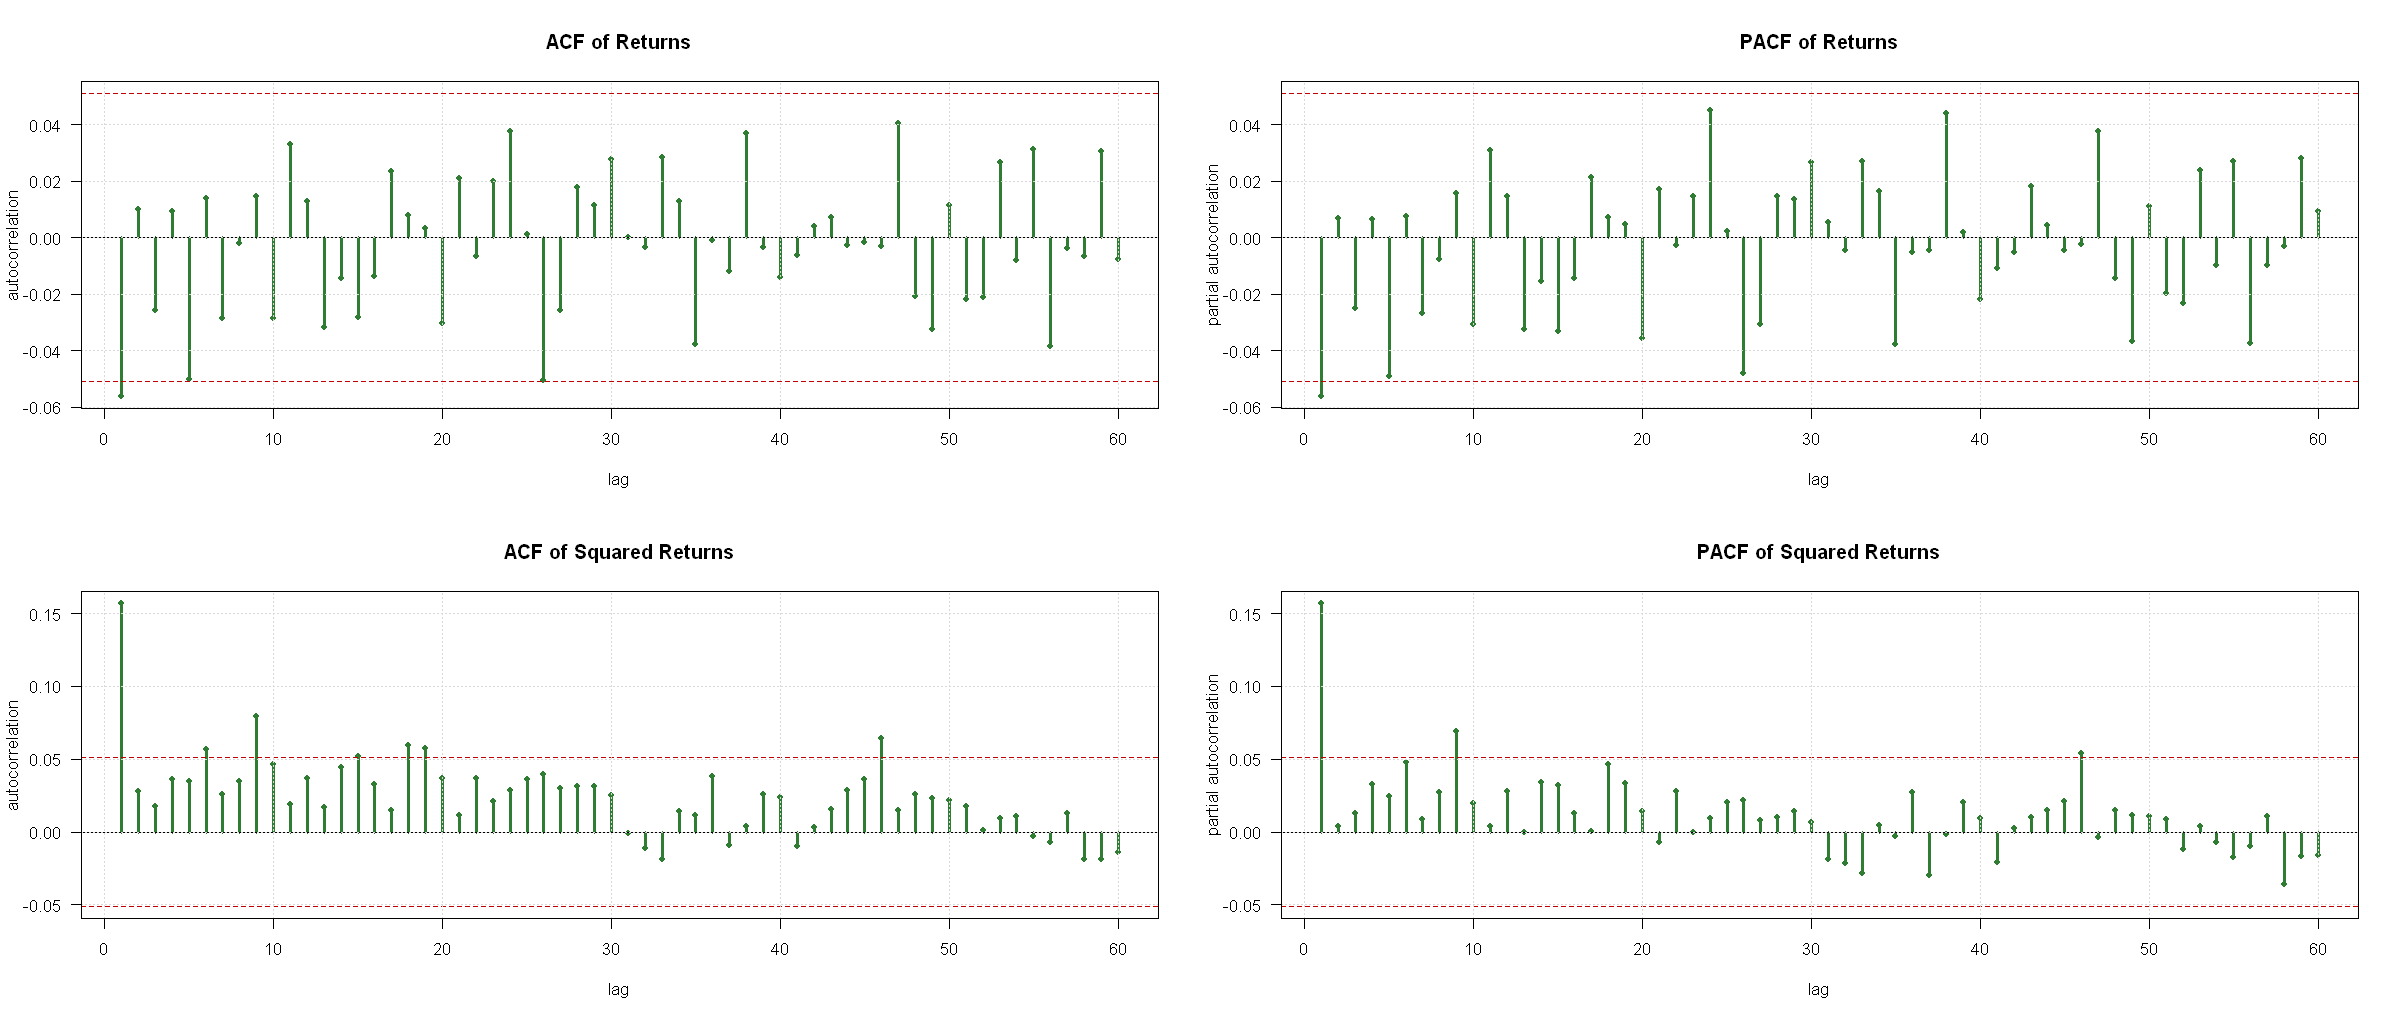

In [10]:
# print ACF and comparison tables 
cat("\nFigure 3: ACF and PACF of Returns and Squared Returns\n\n")
par(mfrow = c(2,2))
plot_acf(df$ret,
    main = "ACF of Returns")

plot_pacf(df$ret,
     main = "PACF of Returns")
plot_acf(df$ret^2,
    main = "ACF of Squared Returns")

plot_pacf(df$ret^2,
     main = "PACF of Squared Returns")

In [20]:
cat("\nTable 2: AIC and BIC of low order ARMA and GARCH\n\n")
arma_ic_table
garch_ic_table


Table 2: AIC and BIC of low order ARMA and GARCH





|          |   Model   |    AIC    |    BIC    |
|:---------|:---------:|:---------:|:---------:|
|ARMA(0,0) | ARMA(0,0) | -8293.814 | -8283.217 |
|ARMA(1,0) | ARMA(1,0) | -8296.492 | -8280.597 |
|ARMA(0,1) | ARMA(0,1) | -8296.427 | -8280.532 |
|ARMA(1,1) | ARMA(1,1) | -8295.558 | -8274.364 |
|ARMA(2,0) | ARMA(2,0) | -8294.563 | -8273.369 |
|ARMA(0,2) | ARMA(0,2) | -8294.505 | -8273.311 |
|ARMA(2,1) | ARMA(2,1) | -8293.813 | -8267.321 |
|ARMA(1,2) | ARMA(1,2) | -8292.520 | -8266.028 |
|ARMA(2,2) | ARMA(2,2) | -8294.211 | -8262.420 |



|   Model    |   AIC   |   BIC   |
|:----------:|:-------:|:-------:|
| GARCH(1,1) | -5.7782 | -5.7567 |
| GARCH(1,2) | -5.7801 | -5.7550 |
| GARCH(2,1) | -5.7769 | -5.7518 |

The Augmented Dickey-Fuller tests reject the null hypothesis of a unit root for both returns and realised volatility, providing support for stationarity and allowing the analysis to proceed. Prior to estimating the GARCH-type models, the ARMA structure of the conditional mean and the GARCH structure of the conditional variance are examined using the ACF and PACF of returns and squared returns. The ACF and PACF suggest only short-run dependence, which motivates the comparison of low-order ARMA-GARCH specifications. Based on AIC and BIC, ARMA(0,0) and AR(1) show the best fit. Using the correlograms and parsimony, the conditional mean is specified as an AR(1) process. For the conditional variance, low-order GARCH specifications are compared. Since the information criteria and the observed dependence structure favor a parsimonious specification, and because GARCH(1,1) is a standard benchmark that typically captures volatility clustering well, the AR(1)-GARCH(1,1) model is selected.

For the Realised Garch model, the AR(1) term is retained because the information criteria for the ARMA-GARCH model indicate short-run dependence in returns. For the volatility equation, the realised GARCH(1,1) specification is selected as a parsimonious benchmark that allows latent volatility to depend on its own lag and on lagged realised volatility.

### Volatility Models

In [21]:
### print linear models estimates
cat("\nTable 3: Realized-Volatility Models\n\n")
estimates_part1 
estimates_part2 


Table 3: Realized-Volatility Models





Table: Linear Realized-Volatility Models with Newey-West Standard Errors

|   part    |    term     | statistic | AR(1)-RV |   HAR    | HAR-RSV  | HAR-Rskew-RKurt |
|:---------:|:-----------:|:---------:|:--------:|:--------:|:--------:|:---------------:|
| estimates | (Intercept) | estimate  | 0.009*** | 0.004*** | 0.003*** |    0.005***     |
| estimates | (Intercept) | std.error | (0.001)  | (0.001)  | (0.001)  |     (0.001)     |
| estimates |   RV_lag1   | estimate  |  0.208*  |  0.093*  |          |     0.160**     |
| estimates |   RV_lag1   | std.error | (0.096)  | (0.042)  |          |     (0.050)     |
| estimates |   RV_week   | estimate  |          |  0.149   |  0.107   |      0.126      |
| estimates |   RV_week   | std.error |          | (0.153)  | (0.136)  |     (0.134)     |
| estimates |  RV_month   | estimate  |          | 0.433**  | 0.385*** |     0.393**     |
| estimates |  RV_month   | std.error |          | (0.134)  | (0.100)  |     (0.126)     |
| estimates | 



| Parameter | AR(1)-GARCH(1,1) | AR(1)-Realized-GARCH(1,1) |
|:---------:|:----------------:|:-------------------------:|
|    mu     |      0.0010      |          0.0009           |
|    ar1    |     -0.0360      |          -0.0471          |
|   omega   |      0.0000      |          0.8909           |
|  alpha1   |      0.0498      |          0.8639           |
|   beta1   |      0.9174      |          0.6536           |
|   shape   |      6.0113      |          10.9922          |
|   eta11   |        NA        |          -0.0233          |
|   eta21   |        NA        |          0.0368           |
|   delta   |        NA        |          0.3135           |
|  lambda   |        NA        |          0.2642           |
|    xi     |        NA        |          -1.7941          |


Figure 4: Linear Realized-Volatility Models Fits



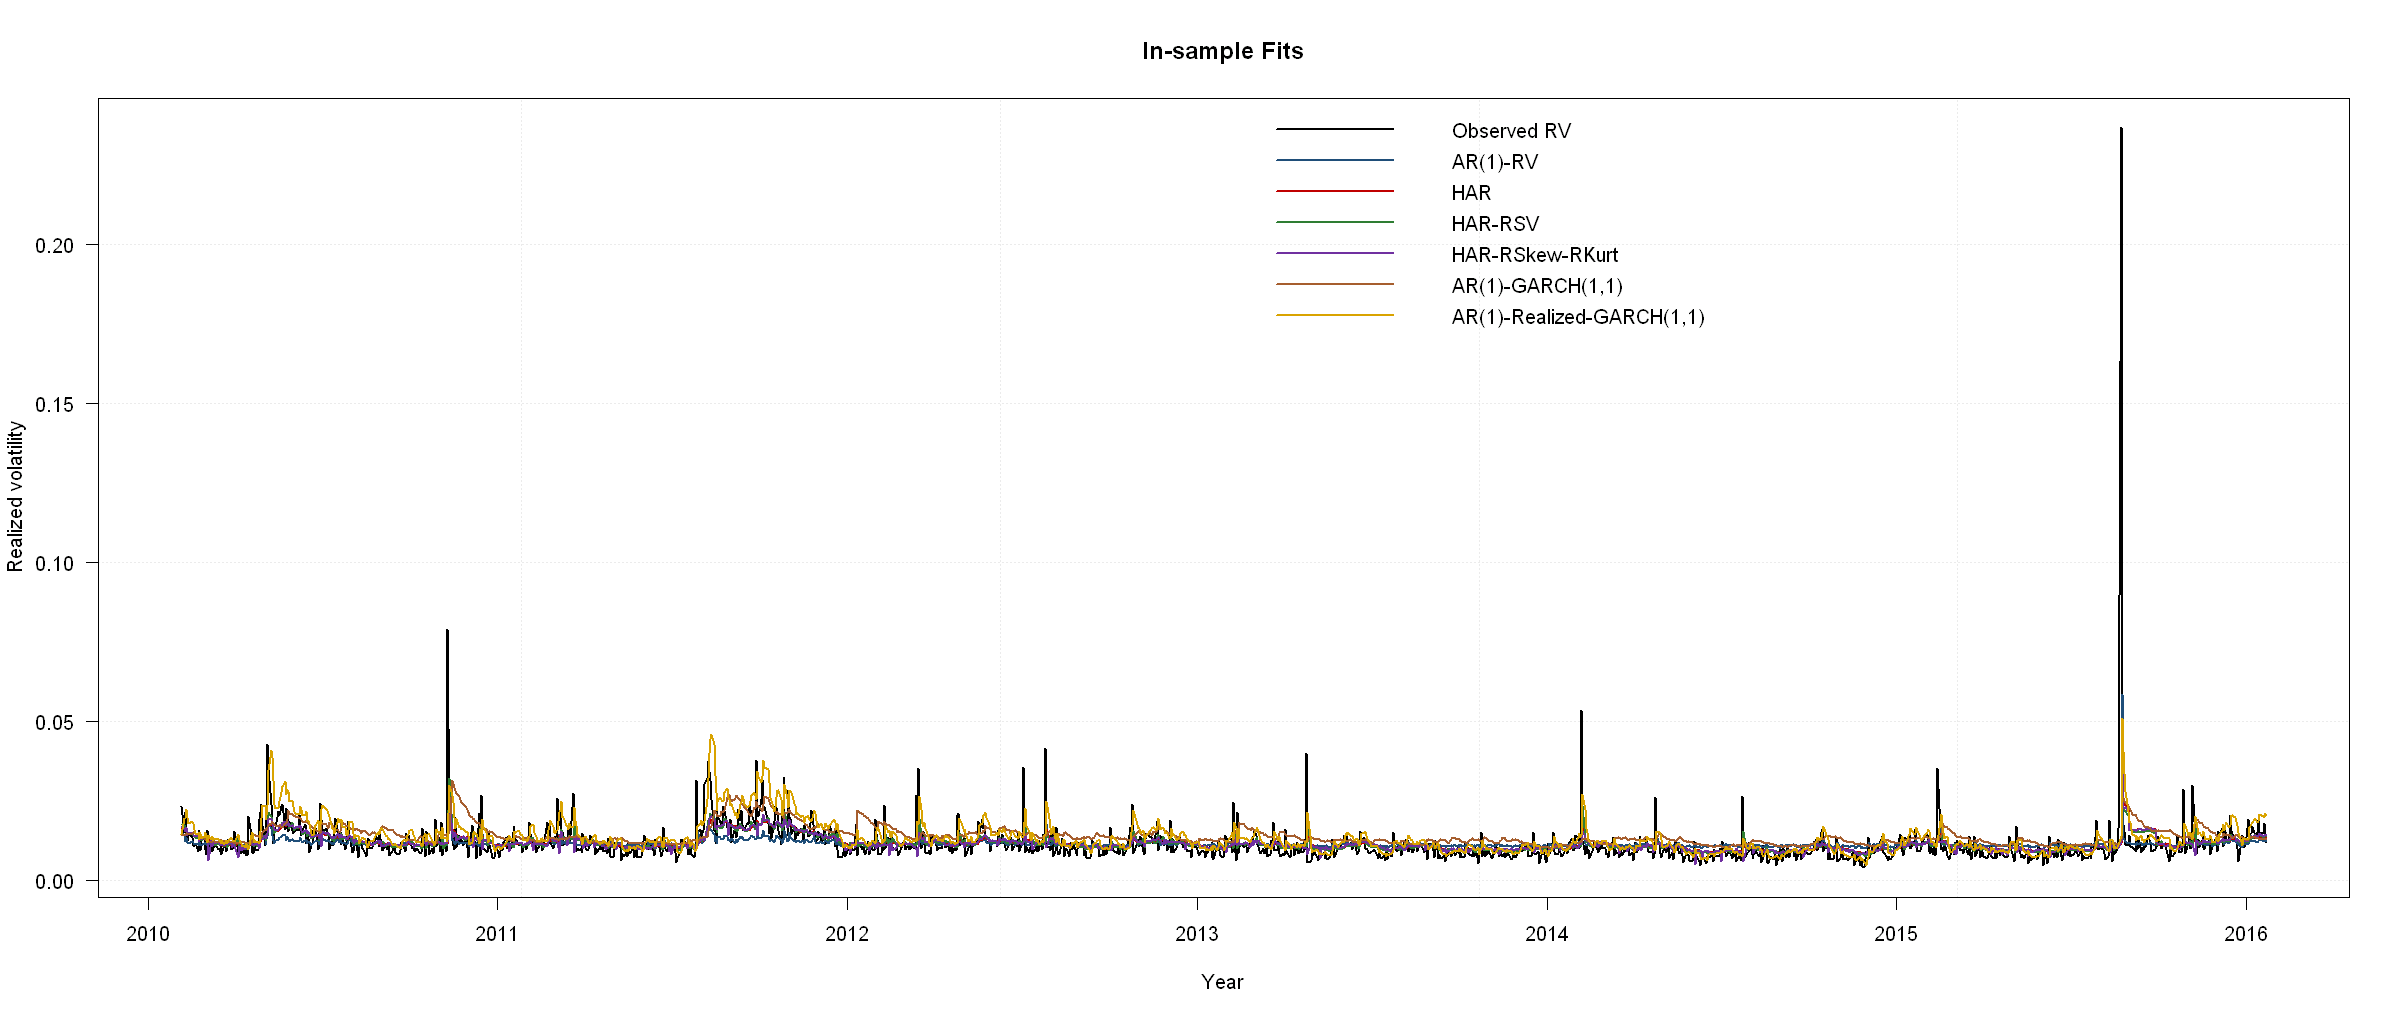

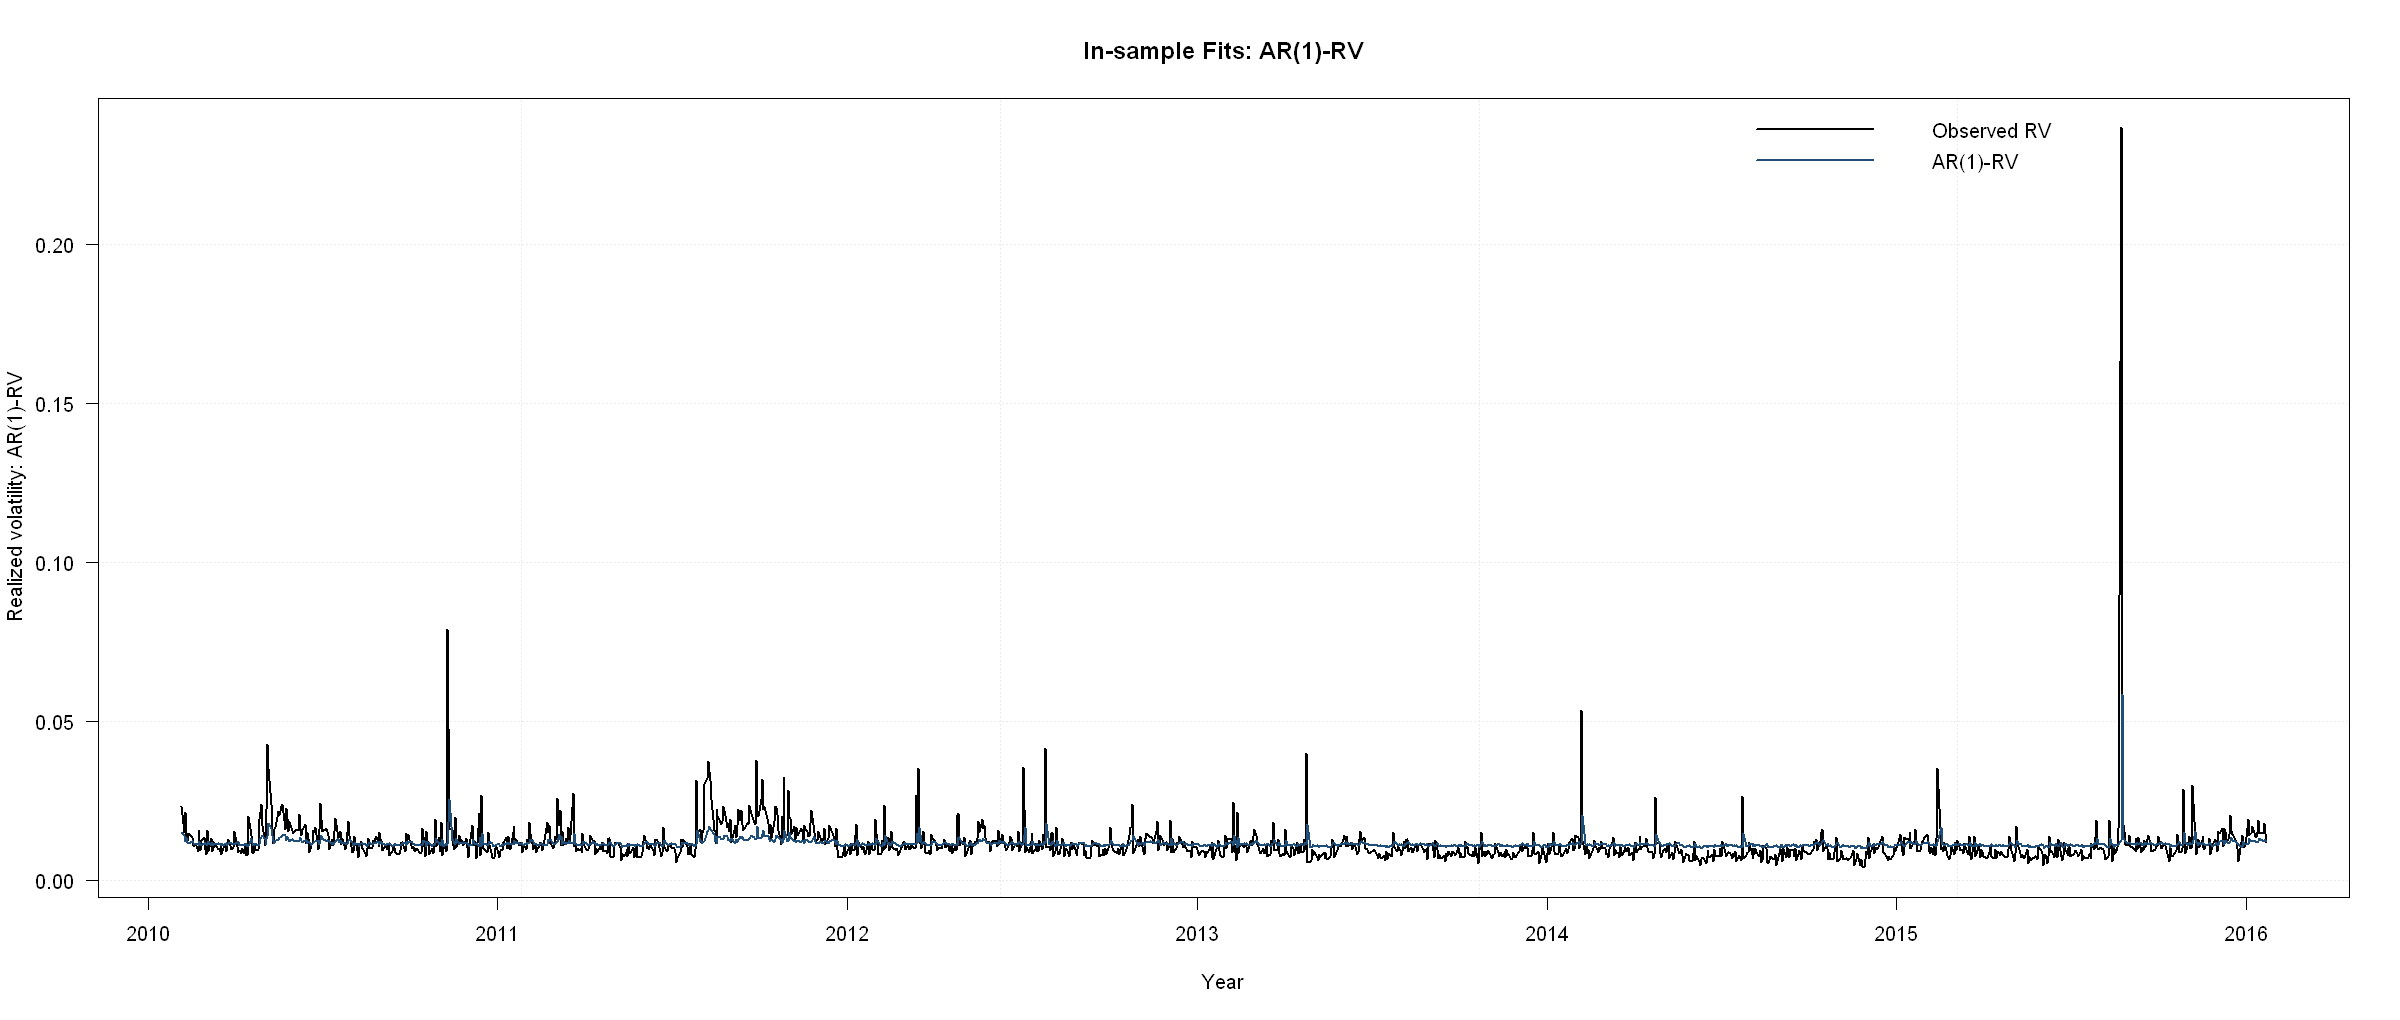

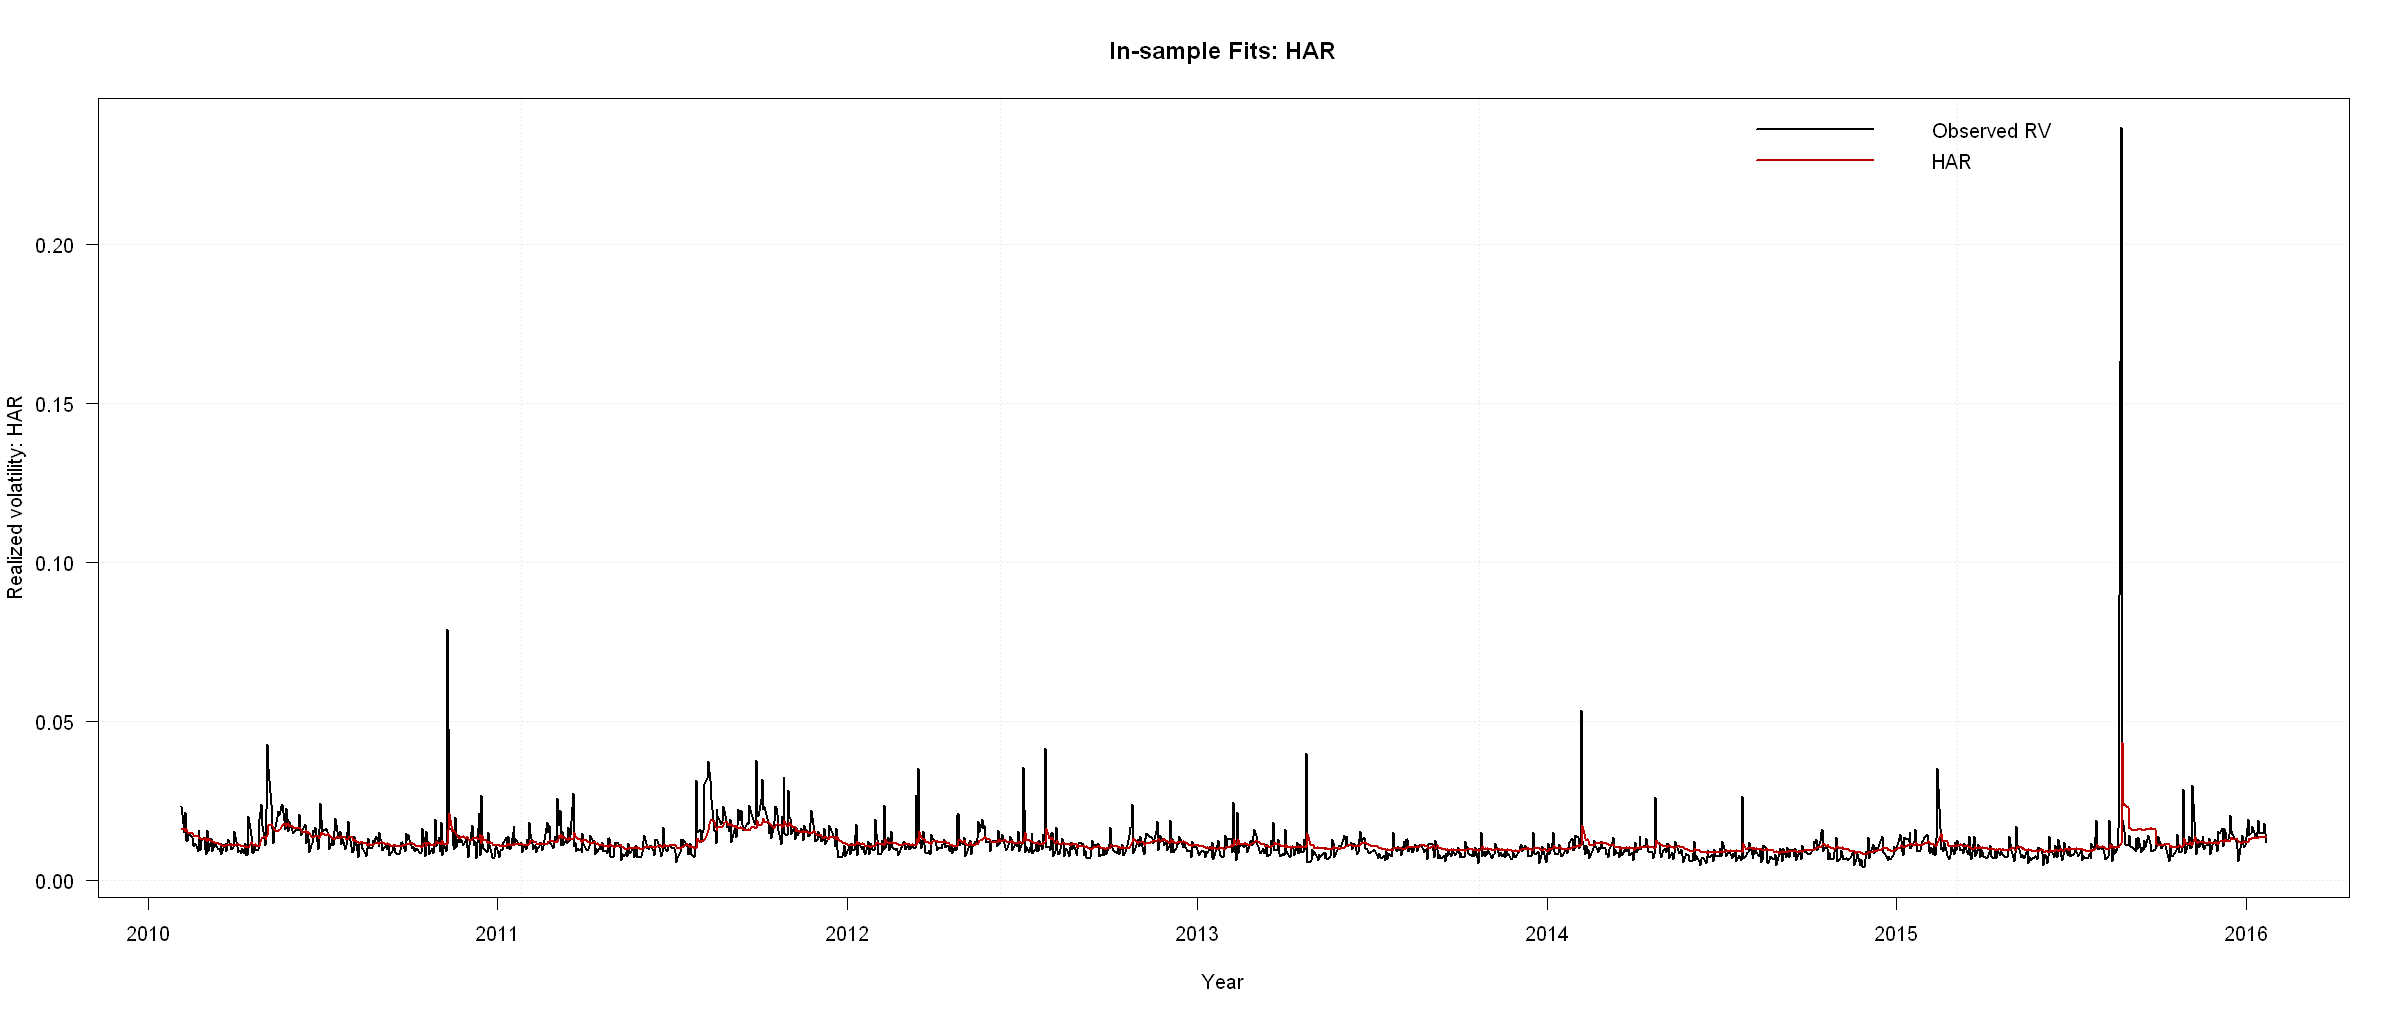

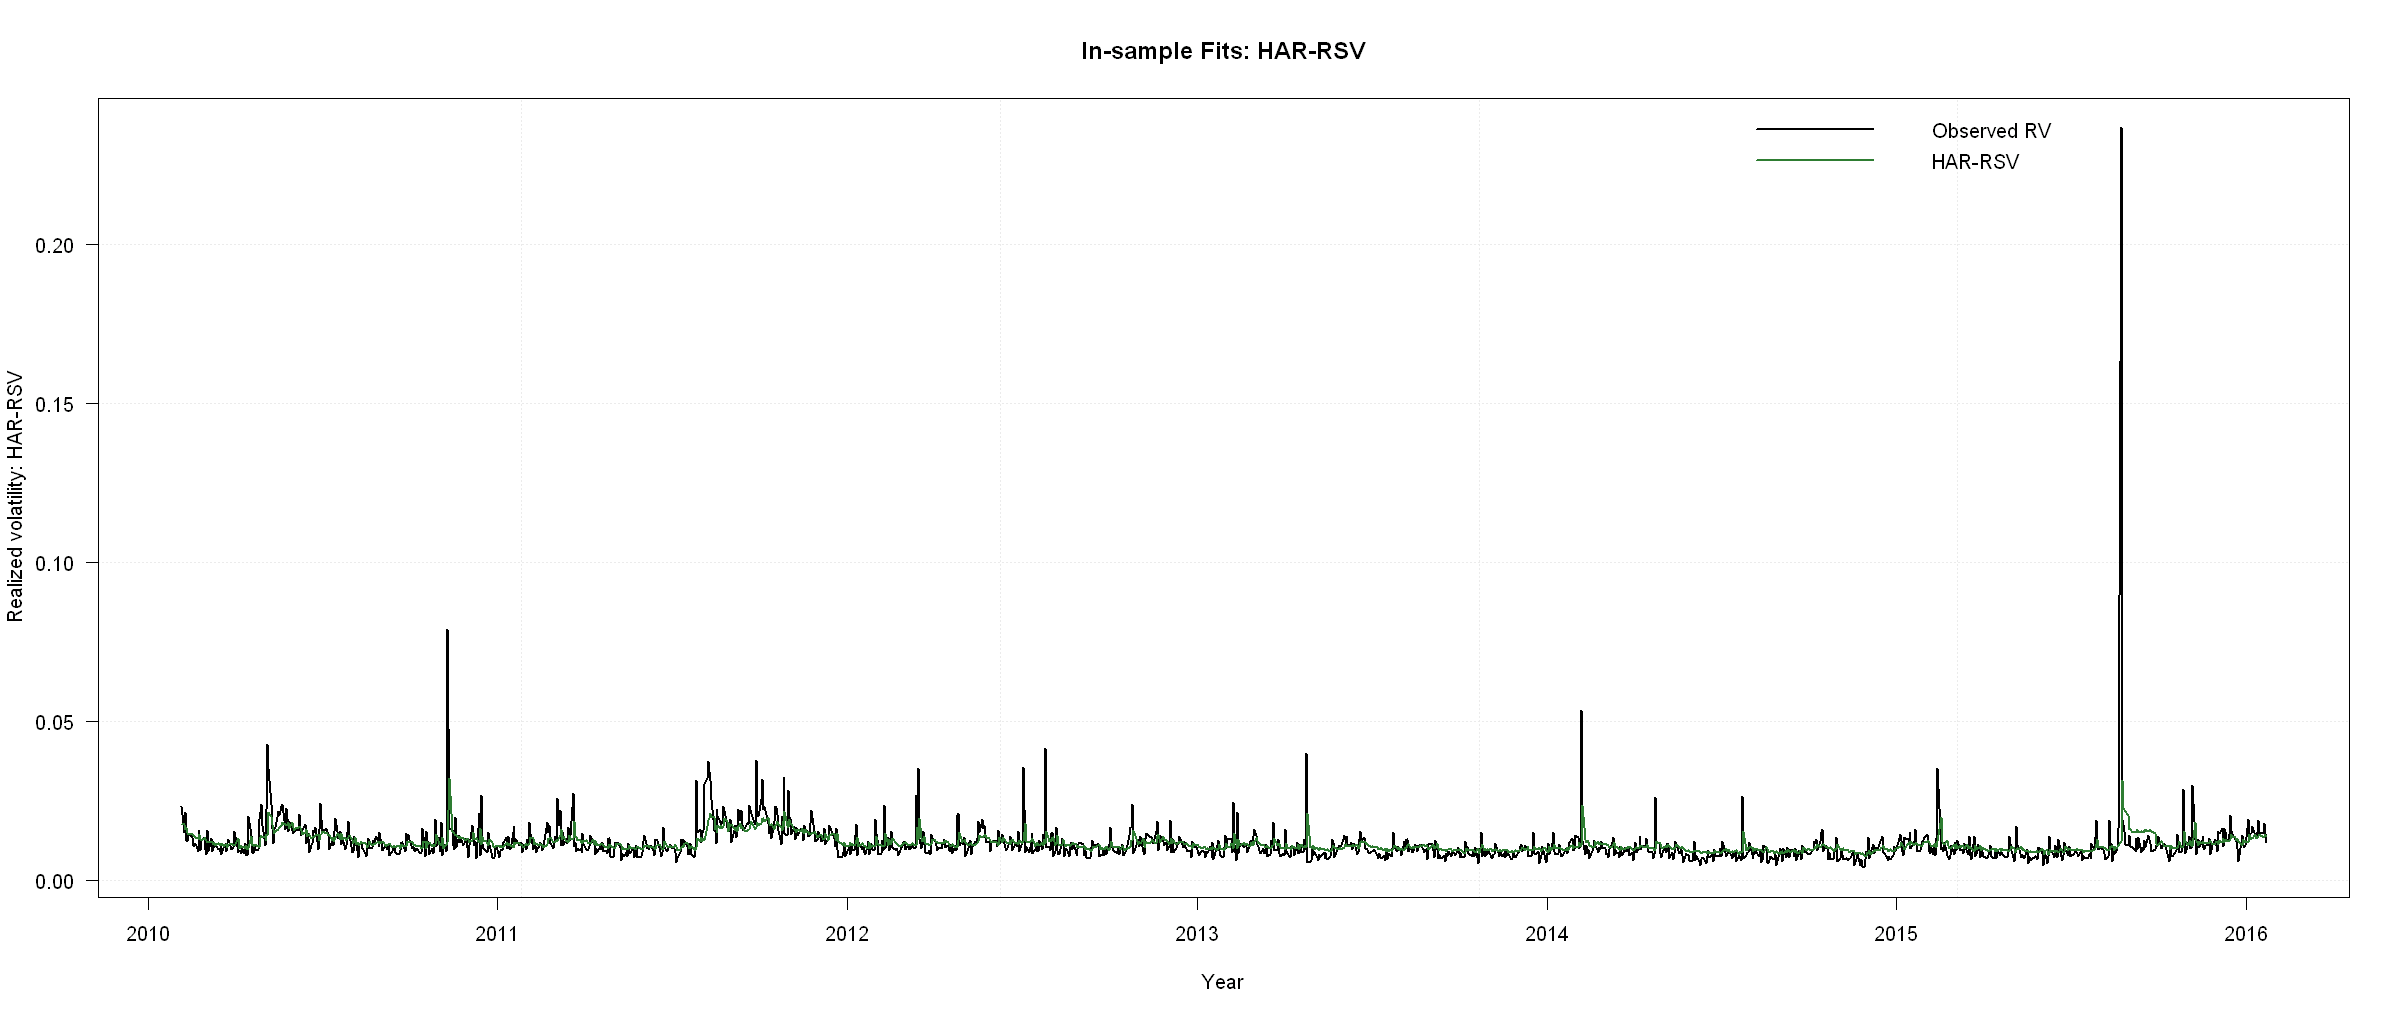

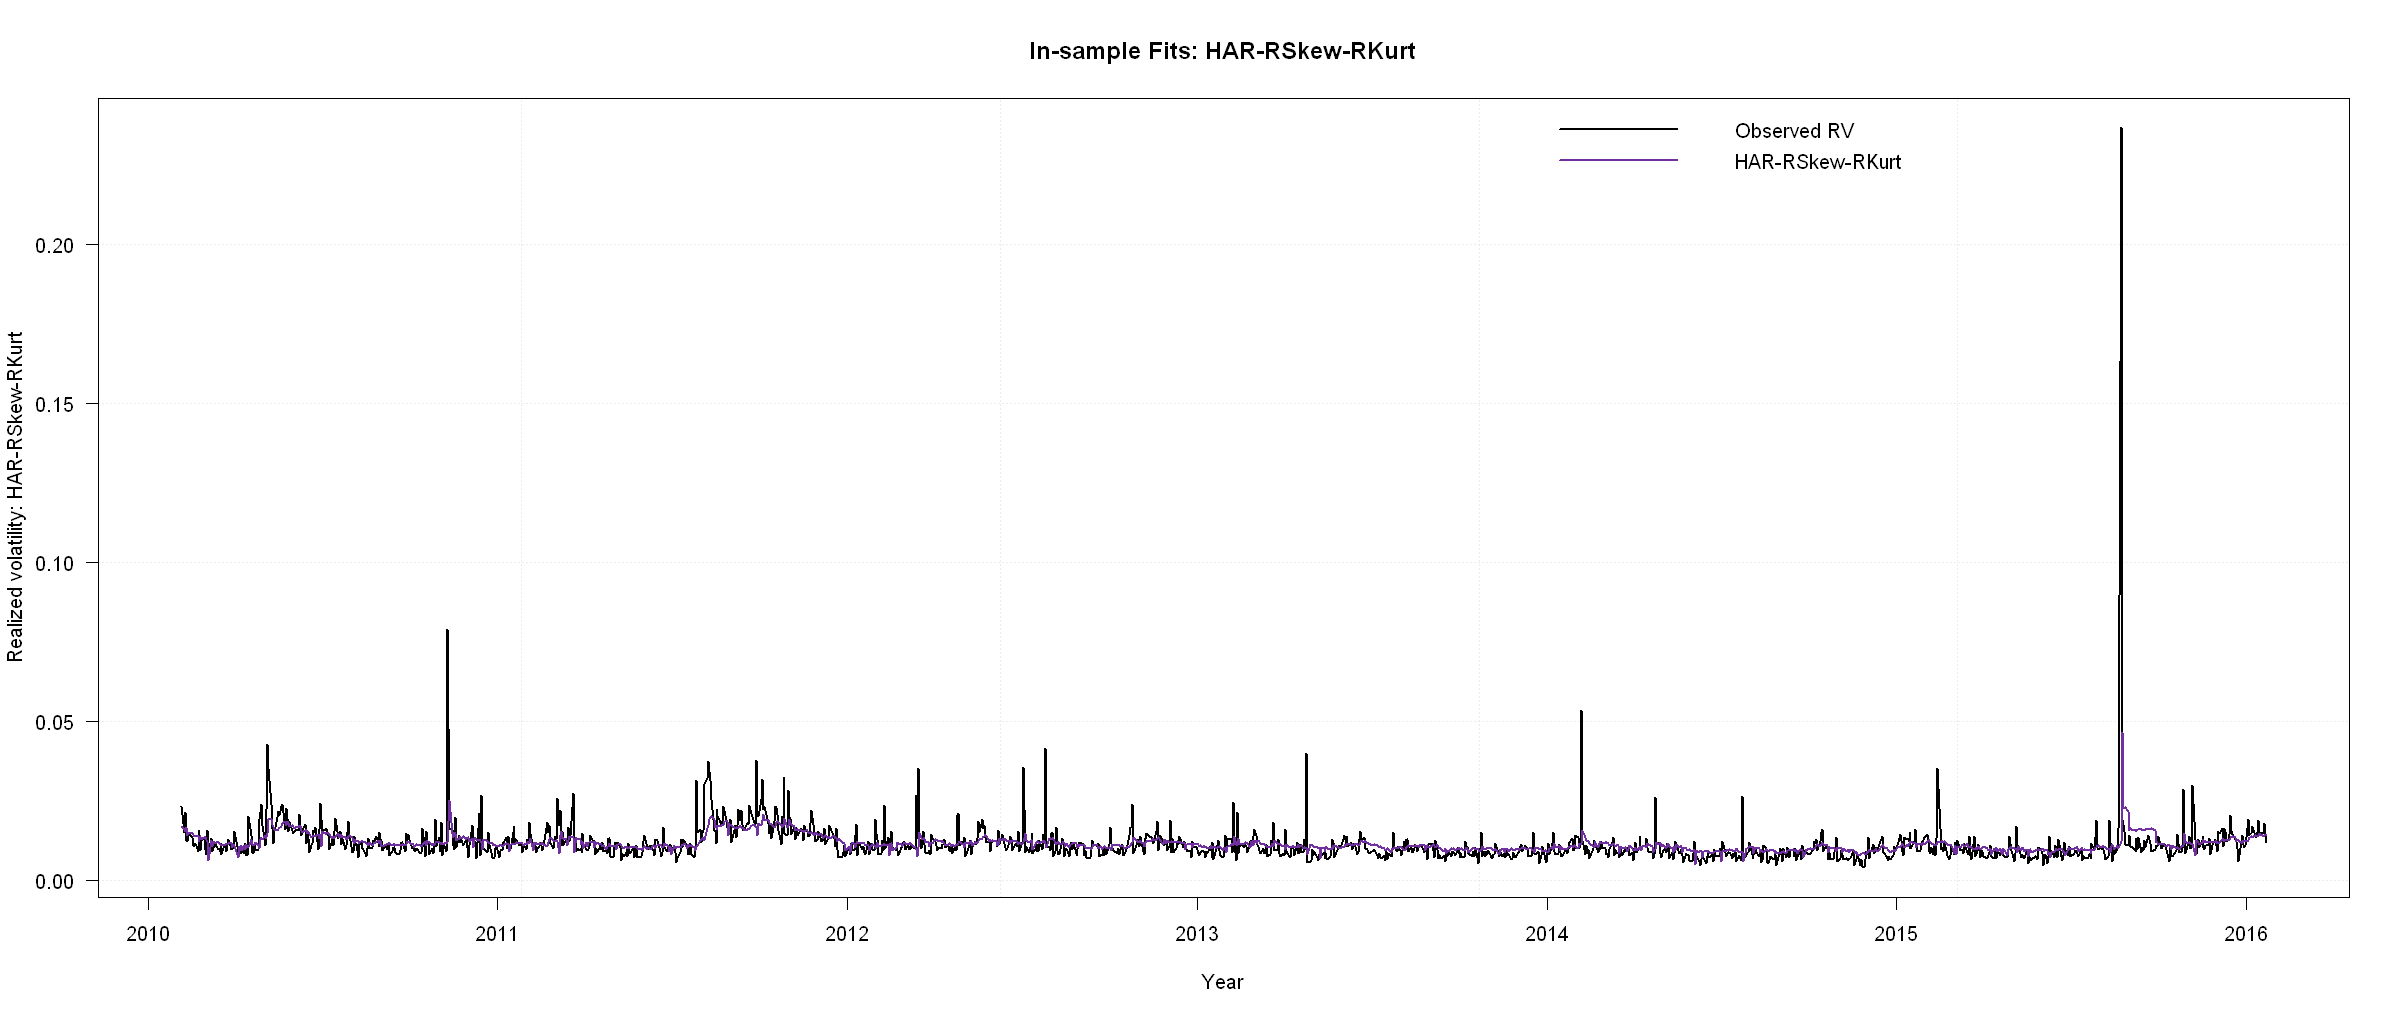

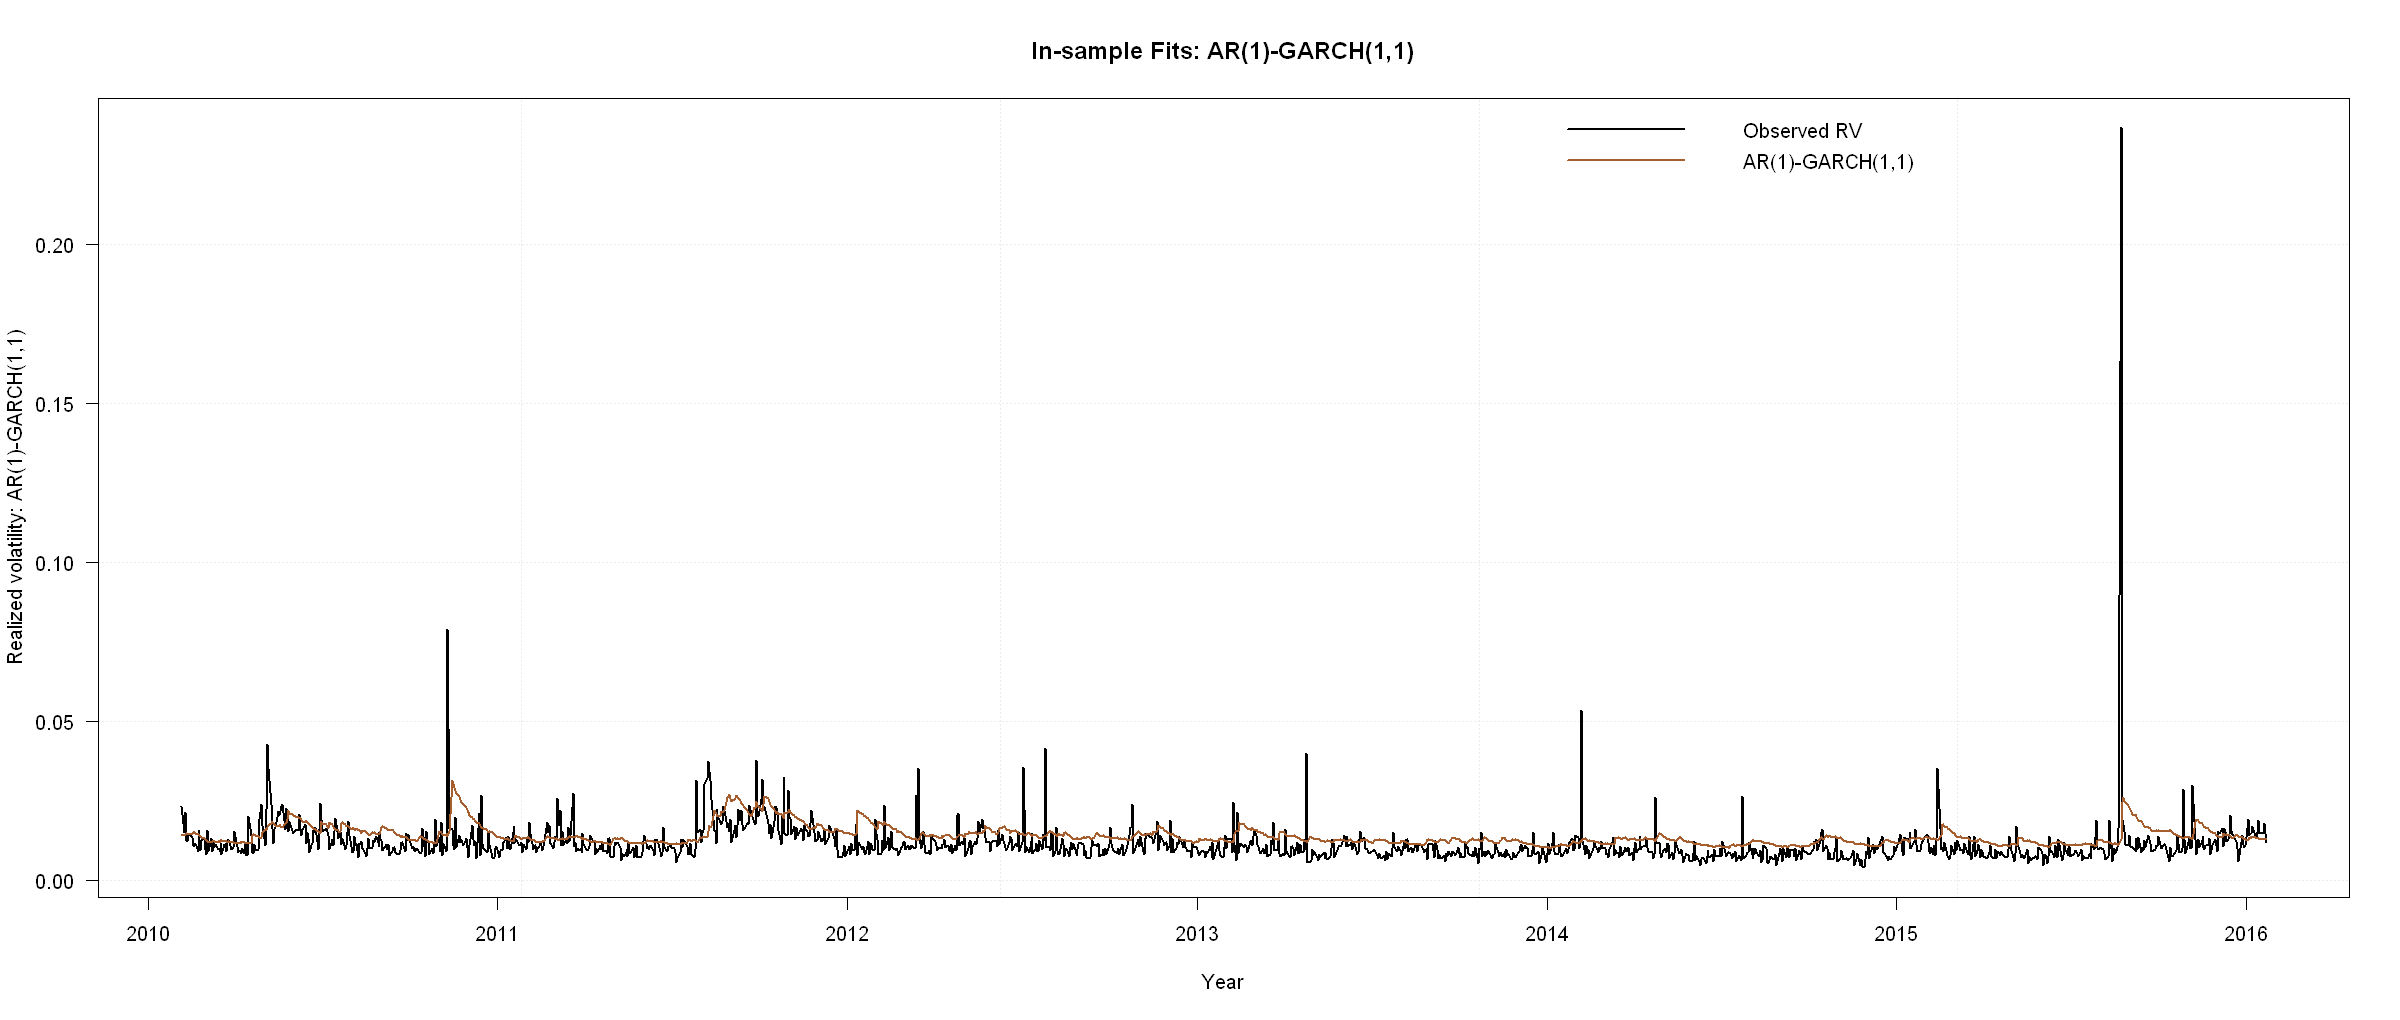

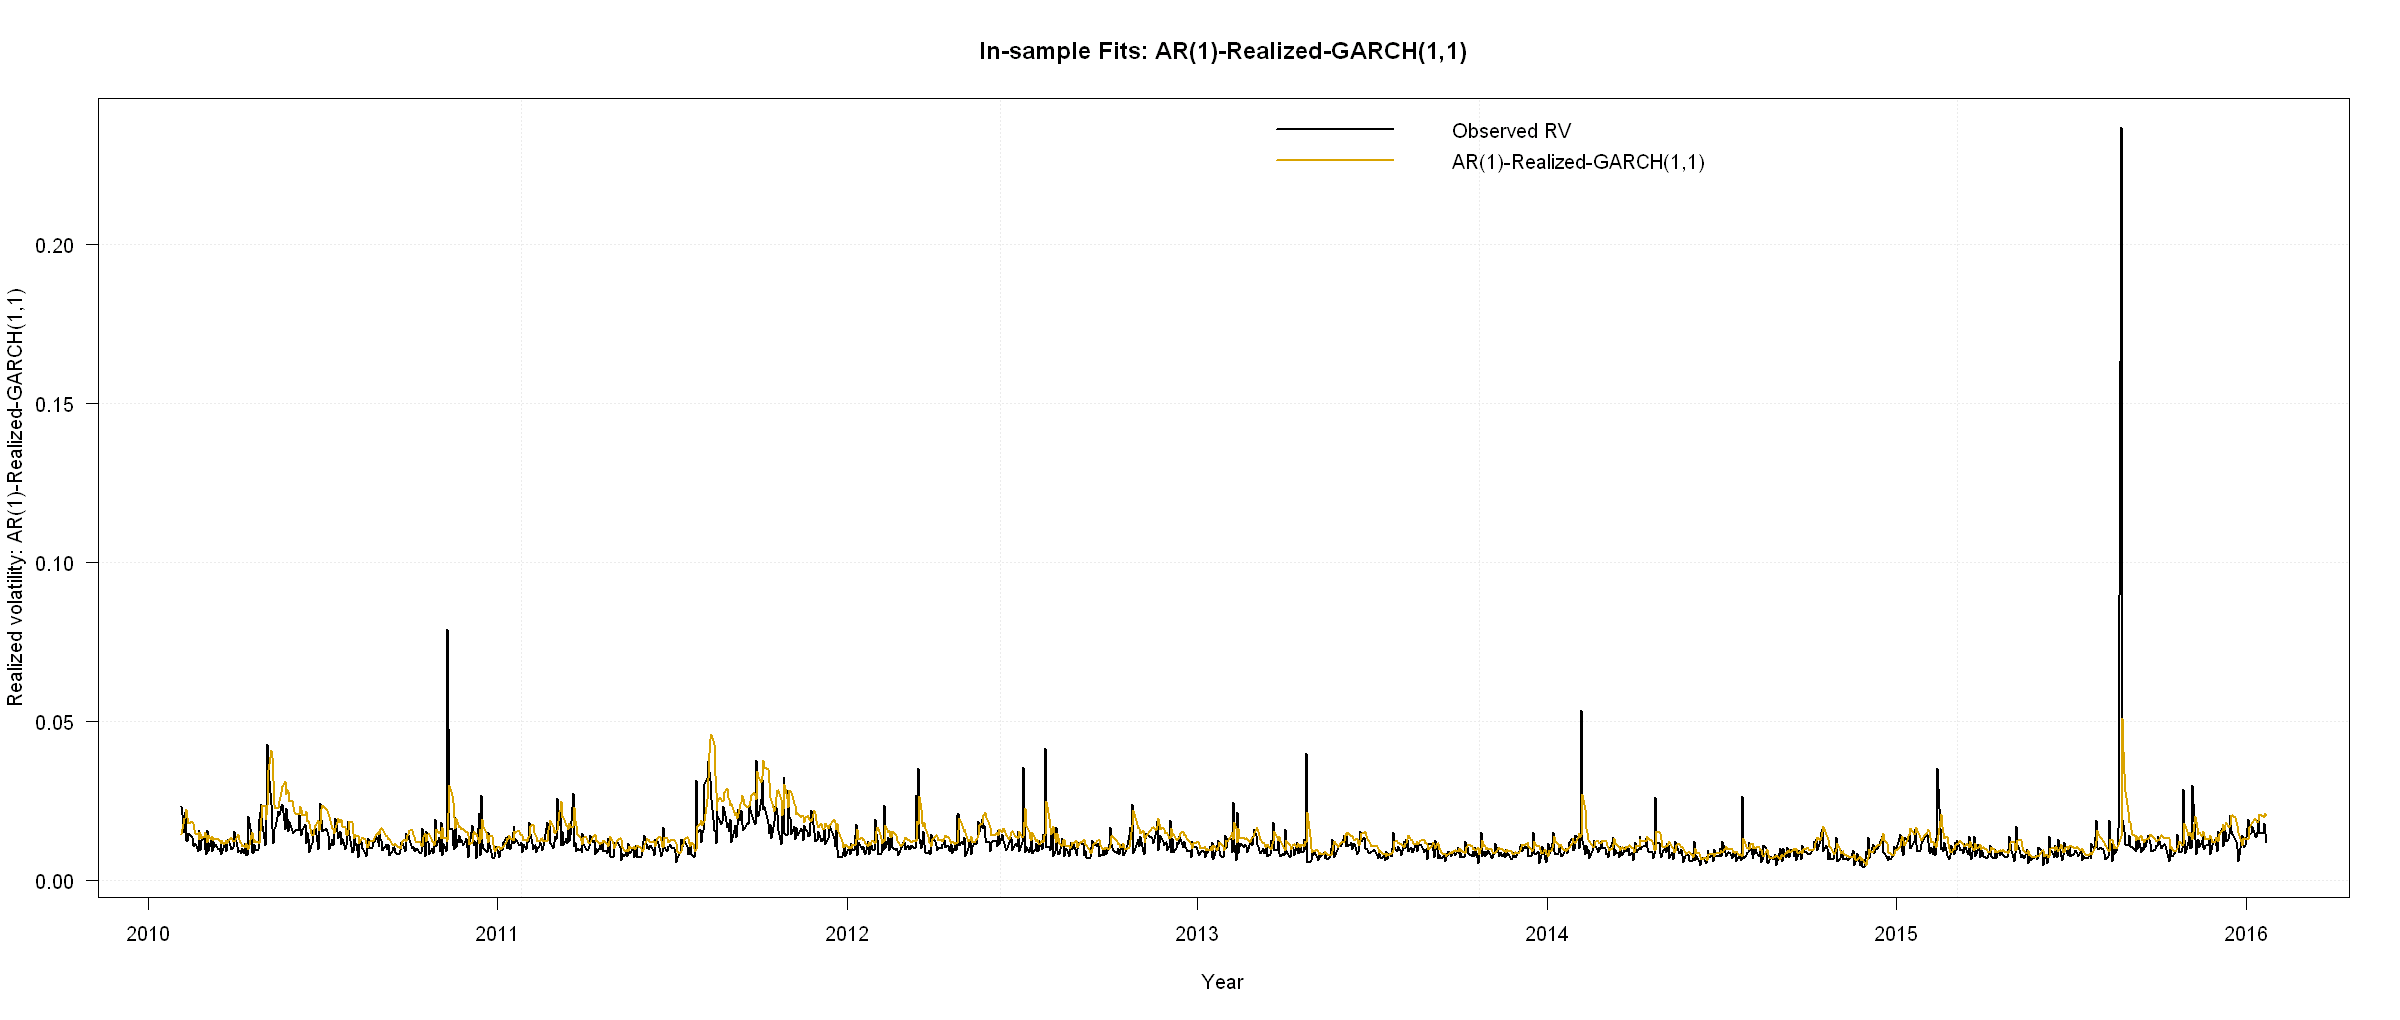

In [22]:
cat("\nFigure 4: Linear Realized-Volatility Models Fits\n\n")

fits <- list(
  "AR(1)-RV" = df$fit_ar1_RV,
  "HAR" = df$fit_har_RV,
  "HAR-RSV" = df$fit_harrs_RV,
  "HAR-RSkew-RKurt" = df$fit_har_skew_kurt_RV,
  "AR(1)-GARCH(1,1)" = df$fit_armagarch_RV,
  "AR(1)-Realized-GARCH(1,1)" = df$fit_realgarch_RV
)

fit_cols <- c(my_cols["navy"], my_cols["red"], my_cols["green"], my_cols["purple"], my_cols["brown"], my_cols["ochre"])

plot_multi_ts(date = df$date, y_list = c(list(df$RV), fits), labels = c("Observed RV", names(fits)),
              main = "In-sample Fits", ylab = "Realized volatility",
              cols = c(my_cols["black"], fit_cols))

for (i in seq_along(fits)) {
  plot_multi_ts(date = df$date, y_list = list(df$RV, fits[[i]]), labels = c("Observed RV", names(fits)[i]),
                main = paste("In-sample Fits:", names(fits)[i]),
                ylab = paste("Realized volatility:", names(fits)[i]),
                cols = c(my_cols["black"], fit_cols[i]))
}

In [23]:
cat("\nTable 4. MSE and MAE of Volatility Models\n")
comparison_table_IC


Table 4. MSE and MAE of Volatility Models




|           Model           |   MSE    |    MAE    |
|:-------------------------:|:--------:|:---------:|
|         AR(1)-RV          | 5.62e-05 | 0.0030513 |
|            HAR            | 5.35e-05 | 0.0027253 |
|          HAR-RSV          | 5.28e-05 | 0.0027098 |
|      HAR-Rskew-RKurt      | 5.28e-05 | 0.0026796 |
|     AR(1)-GARCH(1,1)      | 6.31e-05 | 0.0041536 |
| AR(1)-Realized-GARCH(1,1) | 6.19e-05 | 0.0036712 |

The HAR models outperform the simple AR(1)-RV model based on the R-squared measures, as well as MSE and MAE. The graphical comparison also suggests that the AR(1)-RV model tends to underestimate volatility. Adding realized semivariance increases explanatory power, whereas adding realized skewness and kurtosis provides only limited additional improvement. Skewness is not statistically significant, while lagged kurtosis is statistically significant but numerically very close to zero, so its economic importance appears limited. Lagged realized volatility, or its semivariance components, enters positively across the specifications. The coefficient estimates suggest that realized volatility is highly persistent, especially at longer horizons. In the HAR models, the monthly realized volatility coefficient is consistently the largest and statistically significant, ranging from about 0.39 to 0.43. This indicates that longer-term volatility has strong predictive power for current realized volatility. Overall, the HAR models capture volatility persistence and clustering better than the simple AR(1)-RV model, although they still underestimate extreme volatility jumps.

The GARCH-type models also point to strong volatility persistence. In the standard AR(1)-GARCH(1,1), the ARCH effect is relatively small, while the GARCH coefficient is large, with alpha1 + beta1 ≈ 0.967. This indicates a highly persistent but still mean-reverting volatility process. The AR(1) estimates are similar across the standard GARCH and realized-GARCH models. However, based on MSE and MAE, the HAR-type models outperform the GARCH-type models. Overall, the GARCH models capture volatility clustering, but they also underestimate extreme jumps. In addition, after sudden drops in volatility, the GARCH forecasts appear to adjust downward more slowly, which is consistent with the high persistence implied by the large GARCH coefficient.
